LINK TABLEU = "https://public.tableau.com/app/profile/mardi.wicaksan/viz/Book1_17757498723780/Story1?publish=yes"

#1. Perkenalan


```
Milestone 2

Nama  : Mardi Wicaksana
Batch : CODA-RMT-016

Program ini dibuat untuk Menganalisis Dataset Disney+ melihat Distribusi Konten konten di pada Platform tersebut

```



#2. Identifikasi Masalah

##Topik Permasalahan
### Latar Belakang
Perkembangan platform streaming seperti Disney+ membuat masyarakat semakin mudah dalam mengakses berbagai jenis hiburan seperti film dan serial TV. Platform ini juga menyediakan banyak konten dari berbagai genre dan negara sehingga pengguna memiliki banyak pilihan untuk ditonton.  

Dengan banyaknya konten yang ada, dilakukanlah analisis data untuk memahami bagaimana distribusi konten konten di dalam platform Disney+, baik berdasarkan waktu rilis tahun dan bulan, jenis konten : Movie dan Tv Show, dan yang paling sering muncul dari genre, pemeran, dan negara. Analisis ini dilakukan untuk melihat pola dari perkembangan konten yang di sediakan di platform Disney+

## Tujuan yang ingin dicapai
Memahami Distribusi dan pola konten pada platform Disney+ berdasarkan  jenis konten Movie dan TV Show, waktu rilis Tahun dan Bulan, negara, genre, pemeran


## Problem Statement Menggunakaan Metode SMART dan 5W + 1H
Specific,Measure,Achiveable,Relevant,TimeBound(SMART)

S = Menganalisis distribusi dan tren konten pada platform Disney+ berdasarkan waktu rilis tahun dan bulan, jenis konten Movie dan TV Show, negara, genre, dan pemeran

M = Menganalisis jumlah konten berdasarkan waktu rilis tahun dan bulan, membandingkan jumlah koten Movie dan TV Show, dan melihat keterlibatan yang paling sering muncul dari genre, negara, dan pemeran.


A = Analisis dilakukan menggunakan dataset Disney+ dengan tools Python untuk pengolahan data, visualisasi data menggunakan library seperti Matplotlib dan pyplot, serta Tableau untuk pembuatan dashboard. Selain itu, analisis juga didukung dengan metode statistik deskriptif dan inferensial menggunakan berbagai jenis Library analisis python.

R = Memahami pola distribusi dan perkembangan konten pada platform Disney+

T = Analisis ini direncanakan selesai dalam waktu 1-2 minggu, mulai dari pengelolahan data, visualisasi, hingga kesimpulan

Problem Statement: Disney+ memiliki banyak berbagai jenis konten, namun belum diketahui pola perilisan kontenya. Maka dilakukan analisis untuk memahami tren perilisan konten agar dapat membantu dalam pengambilan strategi penyediaan konten yang lebih optimal.

5W + 1H

##Penjabaran Masalah
1. Genre apa yang paling dominan pada platform disney+? (What)
2. Pada Bulan apa perilisan konten perilisan konten di Disney+ paling tinggi? (When)
3. Negara mana yang paling banyak muncul pada konten di Disney+? (Where)
4. Bagaimana perbandingan perilisan Movie dan TV Show dari tahun ke tahun di Disney+? (How)
5. Apakah terdapat hubungan antara tahun perilisan dan jenis konten di disney+?
(Why)(Inferensial)
6. Siapa aja Cast/Pemeran yang paling sering muncul di Disney+ ? (WHO)
7. Bagaimana gambaran statistik jumlah konten yang dirilis di Disney+ setiap tahun?(Deskriptif)




#3. Data Loading

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download("shivamb/disney-movies-and-tv-shows")

print("Path to dataset files:", path)

100%|██████████| 131k/131k [00:00<00:00, 43.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/disney-movies-and-tv-shows/versions/2


In [3]:
df_disney_plus = pd.read_csv(f"{path}/disney_plus_titles.csv")


In [4]:
df_disney_plus.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


In [5]:
df_disney_plus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1450 non-null   object
 1   type          1450 non-null   object
 2   title         1450 non-null   object
 3   director      977 non-null    object
 4   cast          1260 non-null   object
 5   country       1231 non-null   object
 6   date_added    1447 non-null   object
 7   release_year  1450 non-null   int64 
 8   rating        1447 non-null   object
 9   duration      1450 non-null   object
 10  listed_in     1450 non-null   object
 11  description   1450 non-null   object
dtypes: int64(1), object(11)
memory usage: 136.1+ KB


In [6]:
df_disney_plus.describe()

,release_year
count,1450.000000
mean,2003.091724
std,21.860162
min,1928.000000
25%,1999.000000
50%,2011.000000
75%,2018.000000
max,2021.000000


In [7]:
df_disney_plus.isna().mean()

,0
show_id,0.000000
type,0.000000
title,0.000000
director,0.326207
cast,0.131034
country,0.151034
date_added,0.002069
release_year,0.000000
rating,0.002069
duration,0.000000


In [8]:
df_disney_plus.isna().sum()

,0
show_id,0
type,0
title,0
director,473
cast,190
country,219
date_added,3
release_year,0
rating,3
duration,0


In [9]:
df_disney_plus.shape

(1450, 12)

# 4. Data Cleaning

In [10]:
df_disney_plus["date_added"] = pd.to_datetime(
    df_disney_plus["date_added"], errors="coerce"
) ##merubah Date_added ke Datetime

In [11]:
df_disney_plus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       1450 non-null   object        
 1   type          1450 non-null   object        
 2   title         1450 non-null   object        
 3   director      977 non-null    object        
 4   cast          1260 non-null   object        
 5   country       1231 non-null   object        
 6   date_added    1447 non-null   datetime64[ns]
 7   release_year  1450 non-null   int64         
 8   rating        1447 non-null   object        
 9   duration      1450 non-null   object        
 10  listed_in     1450 non-null   object        
 11  description   1450 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 136.1+ KB


In [12]:
##membuat kolom baru yang hanya mengambil Value Tahun dan Bulan
df_disney_plus['year'] = df_disney_plus['date_added'].dt.year
df_disney_plus['month'] = df_disney_plus['date_added'].dt.month


In [40]:
##melakukan memecah data country  yang berisi data ganda dan membuat data frame baru khusus country untuk mendapatkan negara paling banyak muncul
df_country = df_disney_plus[["show_id","country"]].copy()
df_country['country'] = df_country['country'].fillna('Unknown')

df_country["country"] = df_country["country"].str.split(", ")
df_country = df_country.explode("country")

In [44]:
##Melakukan memecah data genre double di dalam listed in dan membuat data frame baru khusu genre untuk mengetahu genre paling banyak muncul
df_genre = df_disney_plus[["show_id","listed_in"]].copy()
df_genre = df_genre.rename(columns={"listed_in": "genre"})

df_genre["genre"] = df_genre["genre"].str.split(", ")

df_genre = df_genre.explode("genre")


In [42]:
##Melakukan memecah data pemeran di dalam kolom cast dan membuat data frame baru khusus pemeran untuk mengetahui siapa pemeran paling banyak muncul
df_pemeran = df_disney_plus[["show_id","cast"]].copy()
df_pemeran['cast'] = df_pemeran['cast'].fillna('Unknown')

df_pemeran["cast"] = df_pemeran["cast"].str.split(", ")
df_pemeran = df_pemeran.explode("cast")

In [16]:
df_disney_plus.to_csv("disney_plus_titles.csv", index=False)

In [45]:
df_country.to_csv("country.csv", index=False)
df_genre.to_csv("genre.csv", index=False)
df_pemeran.to_csv("pemeran.csv", index=False)

# 5. Analisis dan perhitungan

### Visualisasi

In [18]:
data_type_tahun = df_disney_plus.groupby(["year", "type"])["title"].count().unstack() ## melihat distribusi trend jenis konten dari tahun
data_type_bulan = df_disney_plus.groupby(["month", "type"])["title"].count().unstack() ## melihat distribusi trend jenis konten dari bulan

Bagaimana perbandingan perilisan Movie vs TV Show dari tahun ke tahun? HOW


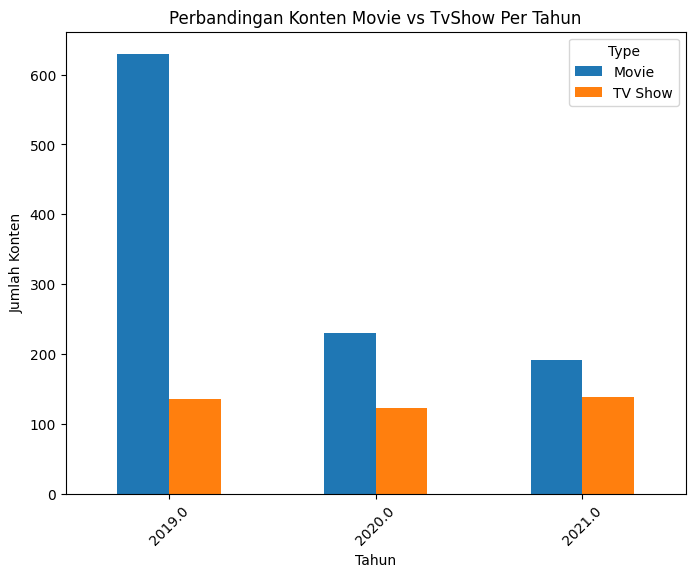

In [19]:
data_type_tahun.plot(kind="bar", figsize=(8,6)) ##Melihat Distribusi Movie dan Tvshow berdasarkan Tahun

plt.title("Perbandingan Konten Movie vs TvShow Per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Konten")

plt.legend(title="Type")  ## Bikin Legend
plt.xticks(rotation=45)

plt.show()

```
insight = Perilisan konten dari 2019 sampai 2021, menunjukan movie memiliki paling banyak konten, sedangkan tvshow lebih kelihatan stabil dari tahun ke tahun, dan di tahun 2019 distribusi movie puncaknya paling tinggi lalu mengalami penurunan di tahun berikutnya kemungkinan dipengaruhi oleh faktor external pada periode tersebut, meskipun tidak dapat dipastikan secara fakta karena keterbatasan data.

Wisdom = Platform Disney+ dapat lebih fokus pada penyediaan konten Movie yang menjadi andalah platform. Selain itu, kestabilan jumlah TV Show menandakan bahwa konten Tvshow tetap dipertahankan untuk menjaga loyalitas pengguna dalam waktu jangka panjang di platform Disney+, agar pengguna tidak hanya datang di periode periode tertentu saja
```

Pada bulan apa perilisan konten di Disney+ paling tinggi?  when

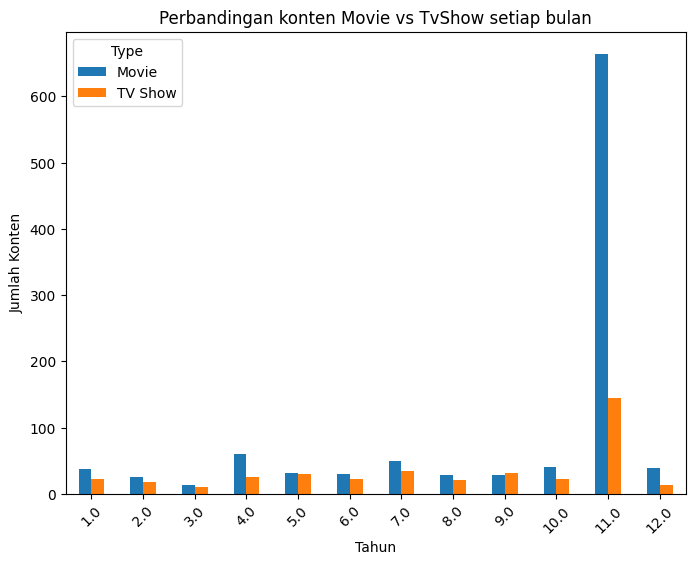

In [20]:
data_type_bulan.plot(kind="bar", figsize=(8,6)) ##Melihat Distribusi Movie dan Tvshow berdasarkan Bulan

plt.title("Perbandingan konten Movie vs TvShow setiap bulan")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Konten")

plt.legend(title="Type")  ## Bikin Legend
plt.xticks(rotation=45)

plt.show()

```
Insight = perilisan konten setiap bulan menunjukkan hampir di setiap bulan perilisan konten Movie lebih banyak dari Tv Show, tetapi di bulan september konten TV Show sedikit lebih tinggi dari Movie, dan di bulan november adalah puncaknya Movie dan TV Show, kemungkinan adanya peningkatan  perilisan konten di bulan november karena menjelang libur akhir tahun dimana banyak orang punya waktu luang.

Wisdom = disney+ dapat memanfaatkan  periode tertentu seperti di bulan november untuk melakukan perilisan konten lebih bnyak di bulan tersebut untuk menarik pengguna terutama Movie, dan disney perlu mempertahankan kestabilan Tv Show setiap bulanya untuk mempertahankan loyalitas pengguna setiap bulanya, tidak hanya datang di saat periode tertentu saja.
```

Negara mana yang paling banyak muncul pada konten di Disney+? Where

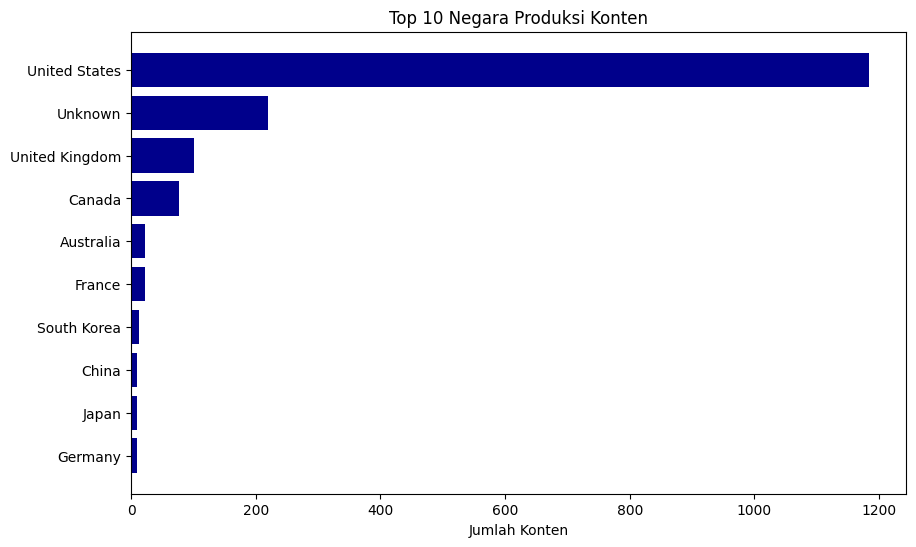

In [21]:
countrydg = df_country['country'].value_counts().head(10).sort_values()


plt.figure(figsize=(10,6))

plt.barh(countrydg.index, countrydg.values, color="darkblue")

plt.title("Top 10 Negara Disney+")
plt.xlabel("Jumlah Konten")

plt.show()

```
Insight = Negara United States memiliki keterlibatan yang tinggi dalam konten disney+ yang ditunjukkan kemunculanya paling tinggi besar dibanding negara lain

Wisdom = Disney+ dapat meperluas kolaborasi konten dari negara lain agar lebih beragam dan meningkatkan variasi pengguna global.
```

Genre apa yang paling dominan pada platform Disney+? what

In [22]:
df_genre['genre'].value_counts().head(10)

,count
genre,
Family,632
Animation,542
Comedy,526
Action-Adventure,452
Animals & Nature,208
Coming of Age,205
Fantasy,192
Documentary,174
Kids,141


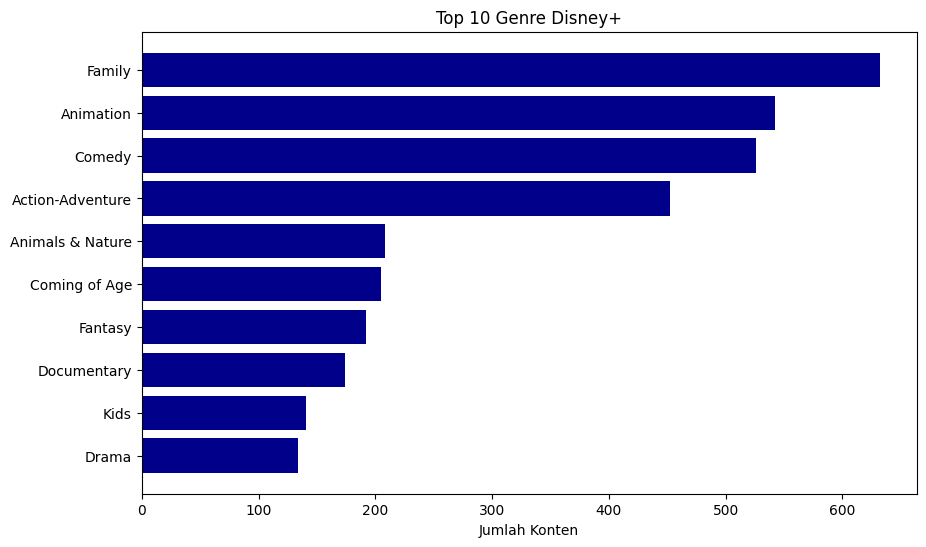

In [23]:
genredg = df_genre['genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(genredg.index.tolist(), genredg.values, color="darkblue")

plt.gca().invert_yaxis()

plt.title("Top 10 Genre Disney+")
plt.xlabel("Jumlah Konten")

plt.show()

```
Insight = Genre yang paling popular di platform Disney+ adalah Family, Animation di no 2, dan Comedy di no 3 kemungkinan pengguna Disney+ banyak menyukai konten bergenre Family, animasi, dan comedy

Wisdom = disney+ dapat fokus mempertahankan genre family animasi dan comedy, sambil menambahkan genre yang lain agar dapat menarik variasi minat pengguna global.
```

Siapa aja Cast/Pemeran yang paling sering muncul di Disney+ ? (WHO)

In [24]:
df_pemeran['cast'].value_counts().head(10)

,count
cast,
Unknown,190
Jim Cummings,33
Walt Disney,20
Bill Farmer,18
Larry the Cable Guy,17
Keith Ferguson,16
Corey Burton,16
Tress MacNeille,16
Pinto Colvig,15


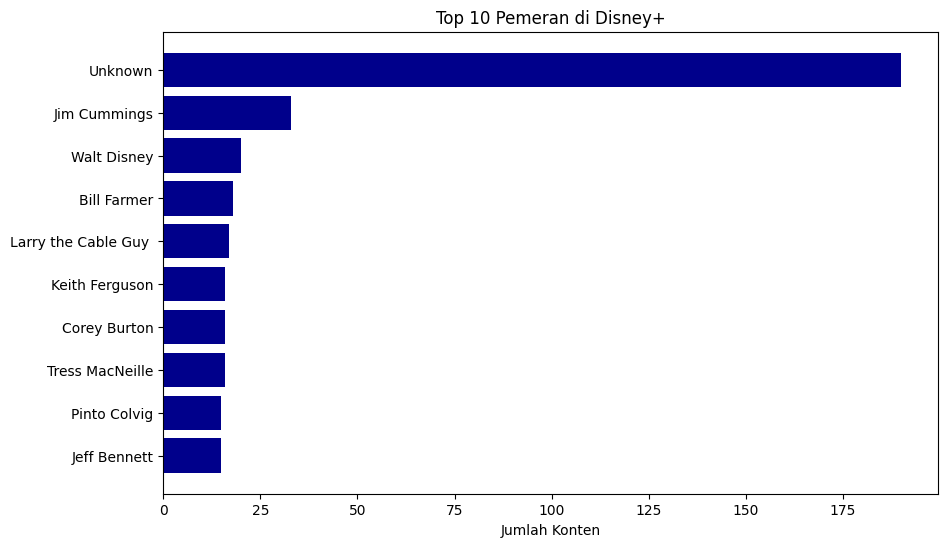

In [46]:
pemerandg = df_pemeran['cast'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(pemerandg.index.tolist(), pemerandg.values, color="darkblue")

plt.gca().invert_yaxis()

plt.title("Top 10 Pemeran di Disney+")
plt.xlabel("Jumlah Konten")

plt.show()

Insight = Jim cummings paling sering muncul di Disney+ sebanyak 33, diikuti oleh Walt Disney sebanyak 20, dan Bill Farmer sebanyak 18.



## Statistik Deskriptif

Setelah di dapatkan hasil perhitungan analisis deskriptif, rata rata jumlah konten pertahun lebih tinggi dibandingkan median(nilai tengah), yang menunjukan distribusi konten tidak merata antar tahun, dan skewnes sebesar 1,7 yang lebih besar dari 0, menunjukan data memiliki kemiringan ke kanan atau positively skewed. Selain itu, nilai minimum sebesar 330 dan maximum sebesar 765 menunjukkan adanya perbedaan jumlah konten antar tahun. lalu nilai standar deviasi sebesar 245 dengan rumus coefficient of variation didapatkan sekitar 50.8% menunjukkan bahwa data memiliki variasi yang tinggi, ini mengindikasikan bahwa distribusi konten per tahunya tidaklah stabil dan terdapat beberapa tahun dengan jumlah distribusi konten yang lebih tinggi di banding tahun lainnya.

Bagaimana gambaran statistik jumlah konten yang dirilis di Disney+ setiap tahun?

### Central Tendency

In [26]:
data_tahun = df_disney_plus.groupby('year')['title'].count() ##melihat distribusi banyak film berdasarkan tahun

In [27]:
print("Rata-rata jumlah judul per tahun:", data_tahun.mean())
print("Median jumlah judul per tahun:", data_tahun.median())


Rata-rata jumlah judul per tahun: 482.3333333333333
Median jumlah judul per tahun: 352.0


didapatkan hasil mean dari rata rata konten pertahun sebesar 482, dan median sebesar 352. jika di lihat nilai rata rata lebih besar dari nilai tengah menandakan adanya jumlah konten pertahun tidak merata, beberapa tahun  dengan jumlah konten yang lebih tinggi dari tahun lainnya.

### Distribution

In [28]:
print("Skew:", data_tahun.skew())

Skew: 1.716357768812939


untuk membuktikan skew ke arah kemiringan positif maka dilakukan perhitungan skew, didapatkan hasil 1.7 mengartikan nilai kemiringan lebih besar dari 0 maka dinyatakan positif skewed

### Measure of Variance

In [29]:
print("Minimum:", data_tahun.min())
print("Maximum:", data_tahun.max())
print("Standard Deviasi:", data_tahun.std())

Minimum: 330
Maximum: 765
Standard Deviasi: 245.04353354727263


In [30]:
print("coefficient of variation:", format(data_tahun.std() / data_tahun.mean() * 100, ".1f"),"%")

coefficient of variation: 50.8 %


Setelah dilakukan perhitungan nilai Min dan Max didapatkan hasil konten pertahun paling kecil sebanyak 330, dan paling besar sebanyak 765 ini menunjukan adanya perbedaan jumlah konten antar tahun, lalu Nilai Standar Deviasi sebesar 245 nilai std lebih besar dari rata rata 482, setelah hasilnya di bagi std/mean dan di kalikan 100 didapatkan hasilnya sebesar 50%, mengartikan jumlah konten pertahun tidak stabil dan memiliki perbedaan yang cukup besar antar tahun.

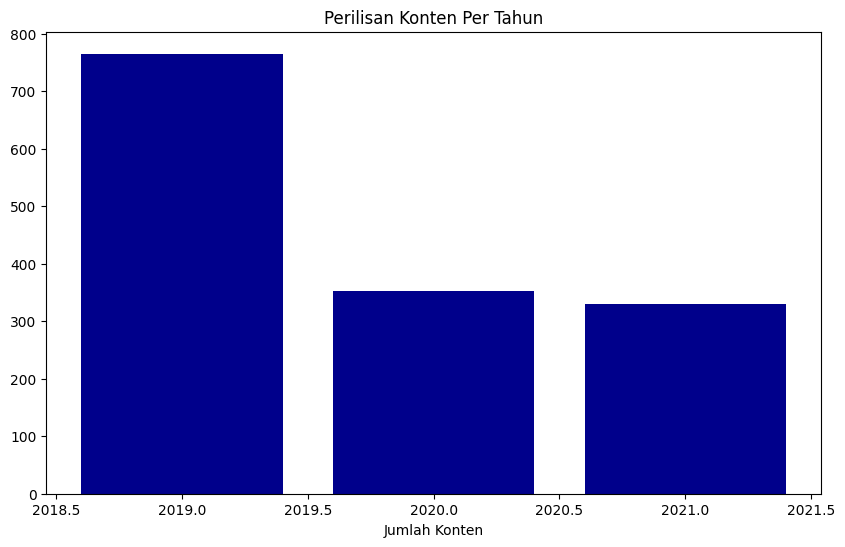

In [47]:
plt.figure(figsize=(10,6))

plt.bar(data_tahun.index, data_tahun.values, color="darkblue")

plt.title("Perilisan Konten Per Tahun")
plt.xlabel("Jumlah Konten")

plt.show()

## Statistik Inferensial

Apakah terdapat hubungan antara tahun perilisan dan jenis konten di Disney+? why

In [31]:
table = pd.crosstab(df_disney_plus["year"], df_disney_plus["type"])
table

type,Movie,TV Show
year,,
2019.0,630,135
2020.0,230,122
2021.0,192,138


In [32]:
df_disney_plus.groupby(["year","type"])["title"].count().unstack()

type,Movie,TV Show
year,,
2019.0,630,135
2020.0,230,122
2021.0,192,138


In [33]:
chi2, p, dof, expected = chi2_contingency(table)
print(f"P-value:{p:.19f}")


P-value:0.0000000000000000032


H0: Tidak terdapat hubungan antara tahun dan jenis konten  
H1: Terdapat hubungan antara tahun dan jenis konten  
a : 0.05

hasil chi squared test p value lebih kecil dari alpha 0.05 jadi menandakan  H0 ditolak dan H1 gagal ditolak, berarti Data antara tahun dan jenis konten terdapat hubungan sehinga hasil perilisan konten tiap tahun tidaklah acak

~~~
Insight = hasil uji chi squared test menunjukkan bahwa jumlah movie dan TV Show berubah ubah dari tahun ke tahun, sehingga perilisan konten movie dan TV Show tiap tahunnya tidak tetap.

Wisdom = Platform Disney+ tidak merilis movie dan TV Show dengan jumlah yang sama tiap tahunnya, tetapi menyesuikan dari waktu ke waktu

~~~

# 6. Pengambilan Kesimpulan

Berdasarkan hasil analisis data pada platform Disney+, diketahui bahwa perilisan konten didominasi oleh Movie dibandingkan TV Show, dengan jumlah yang lebih tinggi di hampir setiap periode. Pola perilisan konten menunjukkan adanya peningkatan pada waktu tertentu, khususnya pada bulan November, serta perubahan jumlah konten dari tahun ke tahun.

Selain itu, genre yang paling dominan adalah Family, diikuti oleh Animation dan Comedy, yang menunjukkan fokus Disney+ pada konten ramah keluarga. Dari sisi geografis, keterlibatan konten masih didominasi oleh United States, sehingga variasi negara produksi masih dapat dikembangkan.

Hasil analisis statistik deskriptif menunjukkan bahwa jumlah konten per tahun memiliki variasi yang cukup besar dan tidak konsisten, sedangkan hasil uji inferensial menunjukkan adanya hubungan antara tahun perilisan dan jenis konten.

Oleh karena itu, Disney+ dapat mengoptimalkan strategi perilisan konten dengan menyesuaikan waktu rilis, meningkatkan variasi genre dan negara produksi, serta menjaga keseimbangan antara Movie dan TV Show agar pengguna tetap aktif dan tertarik dalam jangka panjang.